# Eksperimen SML - Tian

**Nama:** Tian  
**Username Dicoding:** caturseptian  
**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Target:** `diagnosis` (malignant / benign) - klasifikasi biner

Notebook ini mengikuti **Template Eksperimen MSML** dengan tahapan:
1. Import Library
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing (manual)
5. Menyimpan Dataset Hasil Preprocessing

> Catatan: seluruh langkah preprocessing pada notebook ini direplikasi menjadi
> fungsi reusable di `automate_tian.py`.

## 1. Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)
print("Library berhasil diimport")

Library berhasil diimport


## 2. Data Loading

Membaca dataset mentah dari folder `breast_cancer_raw`.

In [2]:
RAW_PATH = "../breast_cancer_raw/breast_cancer_raw.csv"
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
# Informasi struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 3. Exploratory Data Analysis (EDA)

Melihat statistik, distribusi target, missing value, duplikat, dan korelasi.

In [4]:
# Statistik deskriptif
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Proporsi (%):
diagnosis
benign       62.74
malignant    37.26
Name: proportion, dtype: float64


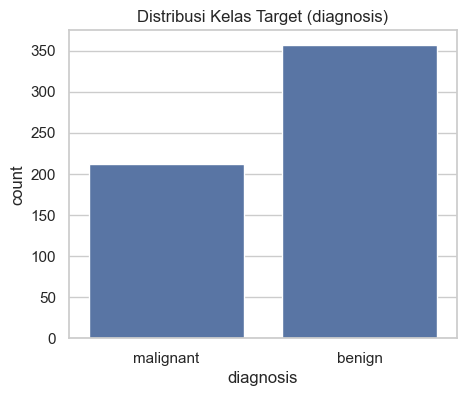

In [5]:
# Distribusi kelas target
target_col = "diagnosis"
print(df[target_col].value_counts())
print()
print("Proporsi (%):")
print((df[target_col].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title("Distribusi Kelas Target (diagnosis)")
plt.show()

In [6]:
# Cek missing value & duplikat
print("Total missing value:", int(df.isna().sum().sum()))
print("Total baris duplikat:", int(df.duplicated().sum()))

Total missing value: 0
Total baris duplikat: 0


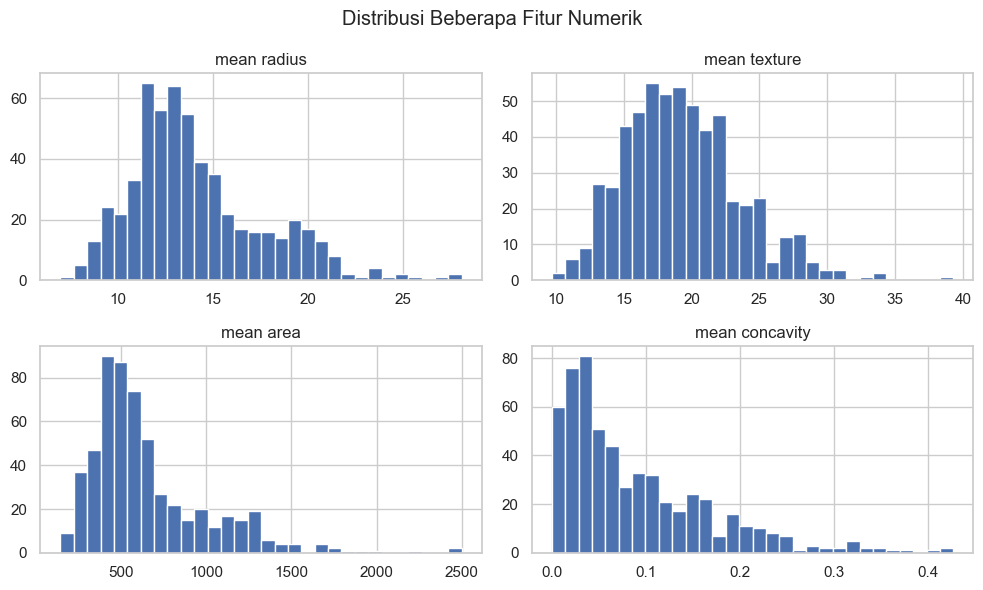

In [7]:
# Distribusi beberapa fitur numerik penting
feat_examples = ["mean radius", "mean texture", "mean area", "mean concavity"]
df[feat_examples].hist(figsize=(10,6), bins=30)
plt.suptitle("Distribusi Beberapa Fitur Numerik")
plt.tight_layout()
plt.show()

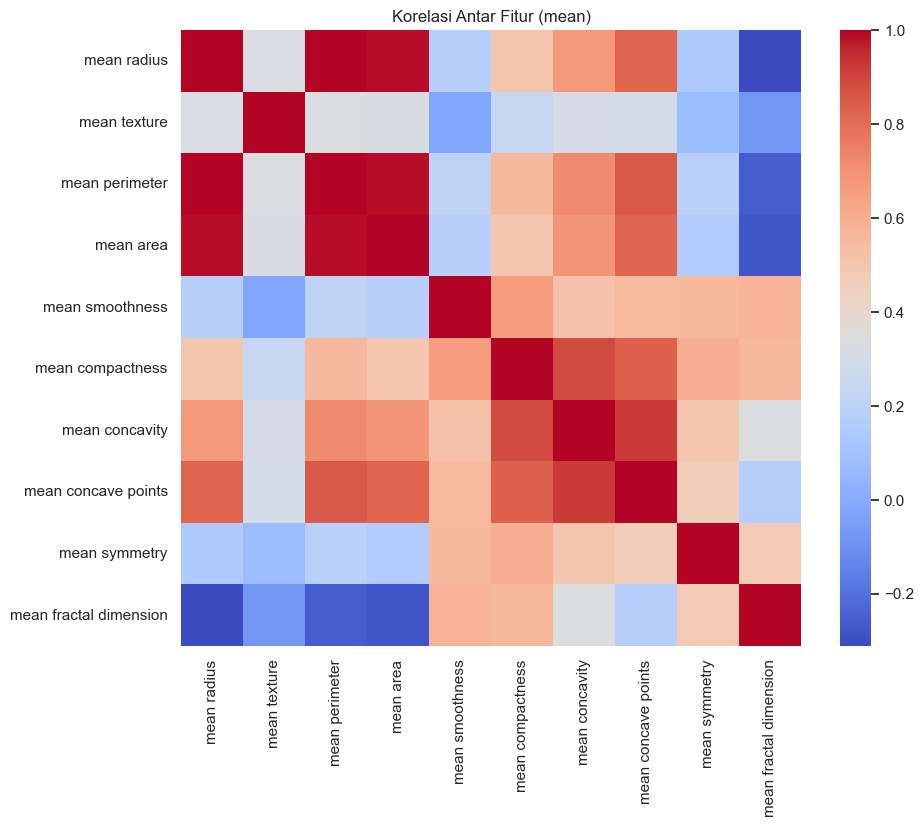

In [8]:
# Heatmap korelasi (subset fitur 'mean' agar mudah dibaca)
mean_features = [c for c in df.columns if c.startswith("mean")]
plt.figure(figsize=(10,8))
sns.heatmap(df[mean_features].corr(), annot=False, cmap="coolwarm")
plt.title("Korelasi Antar Fitur (mean)")
plt.show()

## 4. Data Preprocessing (Manual)

Tahapan preprocessing (identik dengan `automate_tian.py`):
1. Pembersihan data: hapus duplikat & tangani missing value
2. Encoding target: `benign` -> 0, `malignant` -> 1
3. Split data train/test secara stratified
4. Standardisasi fitur numerik (fit hanya pada data train)

In [9]:
# 4.1 Pembersihan data
df_clean = df.copy()
n_dup = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

num_cols = df_clean.select_dtypes(include=[np.number]).columns
n_missing = int(df_clean[num_cols].isna().sum().sum())
if n_missing > 0:
    df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

print(f"Duplikat dihapus: {n_dup}")
print(f"Missing value diisi median: {n_missing}")
print("Shape setelah clean:", df_clean.shape)

Duplikat dihapus: 0
Missing value diisi median: 0
Shape setelah clean: (569, 31)


In [10]:
# 4.2 Encoding target
mapping = {"benign": 0, "malignant": 1}
df_clean[target_col] = df_clean[target_col].map(mapping).astype(int)
print("Distribusi target setelah encoding:")
print(df_clean[target_col].value_counts().to_dict())

Distribusi target setelah encoding:
{0: 357, 1: 212}


In [11]:
# 4.3 Split fitur & target + train/test split (stratified)
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (455, 30) Test: (114, 30)


In [12]:
# 4.4 Standardisasi (fit hanya pada train untuk menghindari data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
train_df[target_col] = y_train.reset_index(drop=True)

test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
test_df[target_col] = y_test.reset_index(drop=True)

train_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,-0.109318,-0.055976,-0.210096,-0.015913,-1.005184,-0.911942,-0.662816,-0.652561,-0.701889,-0.275394,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837,1
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,-0.604378,-1.001046,-0.585429,-0.493454,0.403212,-0.768173,-0.479187,0.114508,-0.142951,-0.577398,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402,0
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,0.303980,1.051501,-0.169545,-0.000809,-0.310104,1.106330,0.622585,0.273685,0.754483,1.508105,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016,0
3,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,-0.545730,-0.621677,0.261427,-0.353585,0.024460,2.090728,1.490561,1.695127,-0.654909,0.767548,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848,1
4,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,1.523863,1.143941,1.282748,1.081313,1.351845,0.107731,0.592927,1.180988,0.301550,0.171527,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249,1


## 5. Menyimpan Dataset Hasil Preprocessing

Menyimpan ke folder `breast_cancer_preprocessing` (train.csv, test.csv, scaler, feature names).

In [13]:
OUTDIR = "breast_cancer_preprocessing"
os.makedirs(OUTDIR, exist_ok=True)

train_df.to_csv(os.path.join(OUTDIR, "train.csv"), index=False)
test_df.to_csv(os.path.join(OUTDIR, "test.csv"), index=False)
joblib.dump(scaler, os.path.join(OUTDIR, "scaler.joblib"))
pd.Series(feature_names).to_json(os.path.join(OUTDIR, "feature_names.json"), orient="values", indent=2)

print("Dataset hasil preprocessing tersimpan di:", OUTDIR)
print(os.listdir(OUTDIR))

Dataset hasil preprocessing tersimpan di: breast_cancer_preprocessing
['test.csv', 'feature_names.json', 'scaler.joblib', 'train.csv']


## Kesimpulan

- Dataset Breast Cancer berhasil dimuat (569 baris, 30 fitur numerik + target).
- Tidak ada missing value maupun duplikat.
- Target di-encode menjadi biner dan distribusinya cukup seimbang.
- Fitur distandardisasi, data dibagi train/test secara stratified.
- Hasil preprocessing disimpan dan siap dipakai untuk pemodelan (Kriteria 2).
- Logika ini direplikasi pada `automate_tian.py` untuk otomasi via GitHub Actions.